# Binomial Probability Distribution

## 1. Definition

The binomial distribution is the distribution of the total number of successes obtained after repeating a Bernoulli experiment several times.

## 2. Intuition

<span style="color:red;">**Out of n trials, how many succeeded?** </span>

<span style="color:green;">**Binomial = sum of independent Bernoulli variables**</span>

## 3. Parameter

$N$: The number of Bernaulli trials

$\theta$: success of each trial

## 4. Support

The Binomial distribution is supported on the set of **nonnegative** integers less than or equal to $N$.

$$N \geq 0$$

## 5. Probability Mass Function

$$
f(n;N,\theta) = \begin{pmatrix}
N \cr
n \cr
\end{pmatrix} \\
\theta^{n} (1 - \theta)^{N-n}
$$

## 6. Cumulative Distribution Function

The CDF evaluated at integers $n$ with $0 \leq n \leq N$

$$
F(n;N,\theta) = \sum_{k=0}^{n} \\
\begin{pmatrix}
N \cr
n \cr
\end{pmatrix} \\
\theta^{k} (1 - \theta)^{N-k}
$$


## 7. Moments

**Mean:** $N\theta$

**Variance:** $N(1-\theta)$

## 8. NumPy Implementation

In [1]:
import numpy as np
import matplotlib as plt

In [225]:
class Binomial:
    """
        Binomial Distribution with N trials and success rate theta.
    """

    def __init__(self, N:int, theta:float):
         
        if not isinstance(N, (int, np.integer)):
            raise TypeError("N must be an integer.")
            
        if N<1:
            raise ValueError("Vale of N should be nonnegative and more than 1")

        if not 0<= theta <= 1:
            raise ValueError("Value of theta should be between 0 and 1")

        self.N = int(N)
        self.theta = float(theta)

    def __factorial(self, value: int) -> int:
        if value == 0 or value==1:
            return 1
        else:
            return value * self.__factorial(value-1)

    def pmf(self, n):

        n = np.asarray(n)

        mask = (
            (n>=0) & (n <= self.N) & (n == np.floor(n))
        )

        P = np.zeros_like(n, dtype=float)

        n_valid = n[mask].astype(int)
      
        numerator = self.__factorial(self.N)

        factorial_n = np.array(
            [self.__factorial(int(i)) for i in n_valid],
            dtype=float,
        )

        factorial_N_minus_n = np.array(
            [self.__factorial(self.N - int(i)) for i in n_valid],
            dtype=float,
        )

        denominator = factorial_n * factorial_N_minus_n
        combination = numerator / denominator

        P[mask] = (
            combination
            * np.power(self.theta, n_valid)
            * np.power(1 - self.theta, self.N - n_valid)
        )

        return P


    def cdf(self, n):
        n = np.asarray(n)

        F = np.zeros_like(n, dtype=float)

        F[n<0] = 0.0

        F[n >= self.N] = 1.0

        mask = (n>=0) & (n<=self.N) & (n == np.floor(n))

        n_valid = n[mask].astype(int)

        cdf_values = []

        for value in n_valid:
            support = np.arange(value + 1)

            cdf_values.append(np.sum(self.pmf(support)))

        F[mask] = cdf_values

        return F

    def cdf_cumsum(self, n):
        n = np.asarray(n)
    
        # Output has the same shape as the input
        F = np.zeros_like(n, dtype=float)
    
        # CDF outside the support
        F[n < 0] = 0.0
        F[n >= self.N] = 1.0
    
        # Valid integer values inside [0, N)
        mask = (
            (n >= 0)
            & (n < self.N)
            & (n == np.floor(n))
        )
    
        # Complete support of the binomial distribution
        support = np.arange(self.N + 1)
    
        # PMF over the full support
        pmf_values = self.pmf(support)
    
        # CDF lookup table
        cumulative_probabilities = np.cumsum(pmf_values)
    
        # Use valid n values as indices
        n_valid = n[mask].astype(int)
    
        F[mask] = cumulative_probabilities[n_valid]
    
        return F

    def mean(self):
        return self.N * self.theta

    def variance(self):
        return self.N * self.theta * (1 - self.theta)

    def sample(self, size=1, random_state=None):
        rng = np.random.default_rng(random_state)
        
        uniform_samples = rng.random((size, self.N))

        return np.sum(uniform_samples<self.theta, axis=1)

    def plot(self, figsize=(10, 4)):
        """
        Plot the PMF and CDF of the Binomial distribution.
        """
    
        import matplotlib.pyplot as plt
    
        support = np.arange(self.N + 1)
    
        pmf = self.pmf(support)
        cdf = self.cdf_cumsum(support)
    
        fig, ax = plt.subplots(1, 2, figsize=figsize)
    
        # PMF
        ax[0].stem(support, pmf)
        ax[0].set_title("Binomial PMF")
        ax[0].set_xlabel("Number of Successes")
        ax[0].set_ylabel("Probability")
        ax[0].grid(True)
    
        # CDF
        ax[1].step(support, cdf, where="post")
        ax[1].set_title("Binomial CDF")
        ax[1].set_xlabel("Number of Successes")
        ax[1].set_ylabel("Cumulative Probability")
        ax[1].set_ylim(0, 1.05)
        ax[1].grid(True)
    
        plt.tight_layout()
        plt.show()

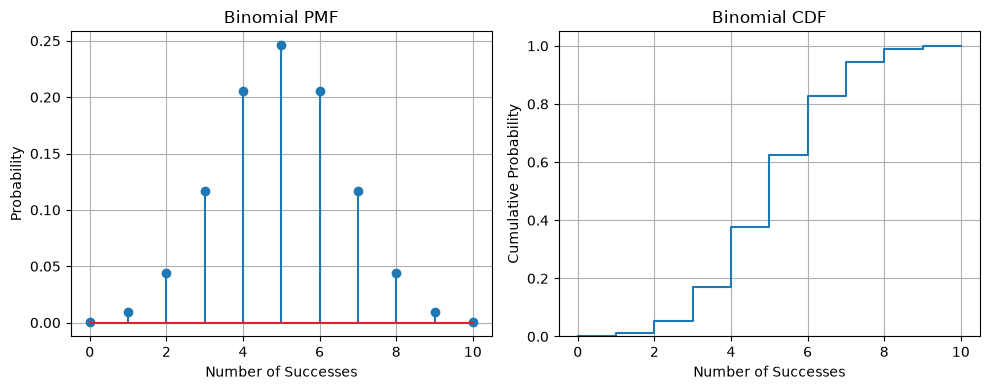

In [229]:
distribution = Binomial(N=10, theta=0.5)
distribution.plot()